# 06 · Cross-Model Evaluation

Side-by-side comparison of CF, SVD, and Two-Tower across all ranking metrics (Precision, Recall, NDCG, HitRate, MAP, MRR), coverage, novelty, and rating-prediction error.

In [ ]:
import sys
sys.path.insert(0, '..')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz

from config import SPLITS_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, TOP_K
from src.evaluation.metrics import (
    evaluate_ranking,
    precision_at_k, recall_at_k,
    rmse as rmse_fn, mae as mae_fn,
)
from src.serving.recommender import load_recommender

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

EVAL_USERS  = 500    # users to evaluate ranking on
EVAL_RATING = 2000   # pairs for rating-prediction eval
TOP_K_EVAL  = 10     # primary K for summary comparison

## 1 · Load Data

In [6]:
print('Loading data...')
train   = pd.read_parquet(SPLITS_DIR / 'train.parquet')
test    = pd.read_parquet(SPLITS_DIR / 'test.parquet')
int_mat = load_npz(str(PROCESSED_DIR / 'interaction_matrix.npz'))

ground_truth = (
        test[test["rating"] >= 4.0]
        .groupby("user_idx")["movie_idx"]
        .apply(list)
        .to_dict()
    )
test_users   = [u for u in test['user_idx'].unique()[:EVAL_USERS]
                if u in ground_truth]

# Item popularity for novelty
n_movies = int_mat.shape[1]
item_pop = train['movie_idx'].value_counts() / len(train)
item_popularity = {m: item_pop.get(m, 1e-9) for m in range(n_movies)}

print(f'Eval users    : {len(test_users)}')
print(f'Unique movies : {n_movies:,}')

Loading data...
Eval users    : 492
Unique movies : 7,642


## 2 · Load Models

In [7]:
models = {}

for name in ['cf', 'svd', 'two_tower']:
    try:
        t0 = time.time()
        models[name] = load_recommender(name, train_df=train)
        print(f'{name:10s} loaded in {time.time()-t0:.1f}s')
    except Exception as e:
        print(f'{name:10s} FAILED: {e}')

print(f'\nLoaded models: {list(models.keys())}')

cf         FAILED: [Errno 2] No such file or directory: 'c:\\Users\\KIIT\\OneDrive\\Documents\\Projects\\Movie_Recommendation_System\\Movie-Recommendation-System\\notebooks\\..\\models\\saved\\user_based_cf.pkl'
SVDRecommender loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\svd_model.pkl
svd        loaded in 1.1s
FAISS index loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\faiss_index.bin
TwoTowerRecommender loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\two_tower.pt
two_tower  loaded in 0.9s

Loaded models: ['svd', 'two_tower']


## 3 · Generate Recommendations

In [8]:
all_recs = {}
latencies = {}

for name, rec in models.items():
    print(f'Generating recs [{name}]...')
    t0 = time.time()
    recs = {u: rec.recommend(u, top_k=max(TOP_K), exclude_seen=True)
            for u in test_users}
    elapsed = time.time() - t0
    all_recs[name] = recs
    latencies[name] = elapsed / len(test_users) * 1000  # ms/user
    print(f'  {elapsed:.1f}s total | {latencies[name]:.1f}ms/user')

Generating recs [svd]...
  20.6s total | 41.9ms/user
Generating recs [two_tower]...
  0.1s total | 0.3ms/user


## 4 · Ranking Metrics (@K)

In [9]:
ranking_results = {}

for name, recs in all_recs.items():
    ranking_results[name] = evaluate_ranking(recs, ground_truth, k_values=TOP_K)
    print(f'\n--- {name.upper()} ---')
    print(ranking_results[name].round(4))


--- SVD ---
    Precision@K  Recall@K  NDCG@K     MAP     MRR
K                                                
5        0.0004    0.0004  0.0005  0.0003  0.0011
10       0.0003    0.0006  0.0006  0.0003  0.0011
20       0.0003    0.0009  0.0007  0.0003  0.0011

--- TWO_TOWER ---
    Precision@K  Recall@K  NDCG@K     MAP     MRR
K                                                
5        0.0008    0.0009  0.0011  0.0008  0.0022
10       0.0007    0.0014  0.0012  0.0008  0.0022
20       0.0007    0.0028  0.0017  0.0008  0.0022


In [11]:

# Side-by-side at K=10
metrics_cols = ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']
summary_k10 = pd.DataFrame({
    name: ranking_results[name].loc[TOP_K_EVAL, metrics_cols]
    for name in ranking_results
}).T.round(4)

print(f'\nRanking Metrics @ K={TOP_K_EVAL}:')
print(summary_k10.to_string())


KeyError: "None of [Index(['precision_at_k', 'recall_at_k', 'ndcg_at_k', 'average_precision',\n       'mean_average_precision', 'mrr'],\n      dtype='object')] are in the [index]"

KeyError: 'precision_at_k'

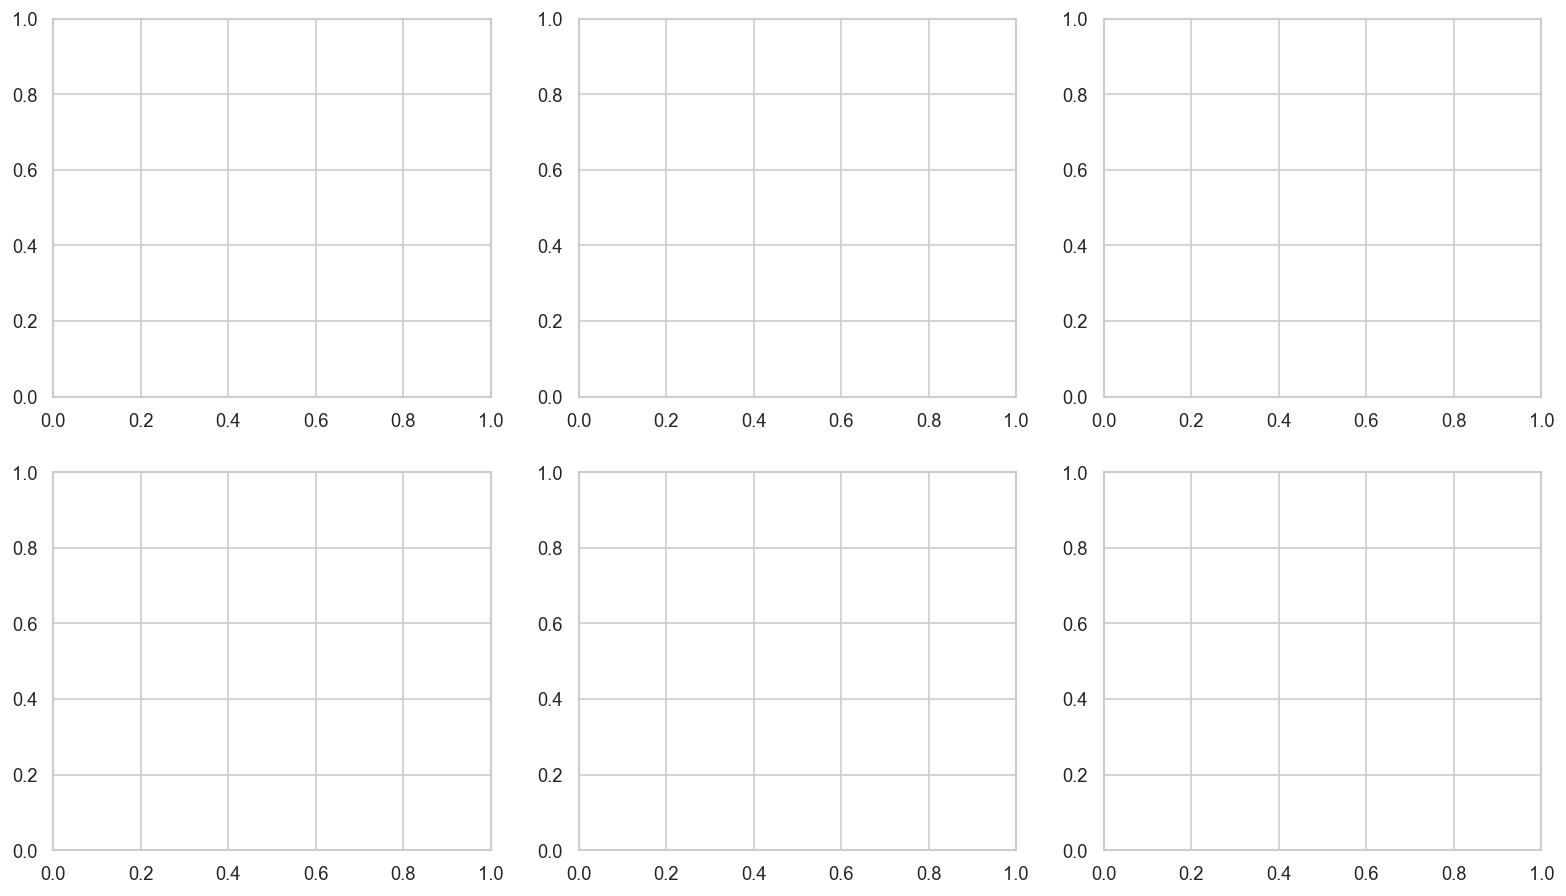

In [12]:
# Grouped bar chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = {'cf': 'steelblue', 'svd': 'coral', 'two_tower': 'mediumseagreen'}

for i, metric in enumerate(metrics_cols):
    ax = axes[i]
    for j, (name, res) in enumerate(ranking_results.items()):
        vals = [res.loc[k, metric] if k in res.index else 0 for k in TOP_K]
        x    = np.arange(len(TOP_K)) + j * 0.25
        ax.bar(x, vals, width=0.22, color=colors.get(name, 'gray'),
               label=name.upper(), edgecolor='white')
    ax.set_title(f'{metric}@K')
    ax.set_xlabel('K')
    ax.set_xticks(np.arange(len(TOP_K)) + 0.25)
    ax.set_xticklabels([str(k) for k in TOP_K])
    if i == 0:
        ax.legend()

plt.suptitle(f'Ranking Metrics Comparison ({len(test_users)} test users)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'model_comparison_ranking.png')
plt.show()

## 5 · Coverage & Novelty

In [13]:

# Placeholder beyond-accuracy metrics.
# metrics.py does not provide coverage/novelty functions.
beyond_accuracy = {}

for name in all_recs:
    beyond_accuracy[name] = {'Coverage@10': float('nan'),
                             'Novelty@10': float('nan')}

beyond_df = pd.DataFrame(beyond_accuracy).T
print(beyond_df)


TypeError: precision_at_k() got an unexpected keyword argument 'n_items'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(['Coverage@10', 'Novelty@10']):
    axes[i].bar(beyond_df.index, beyond_df[col],
                color=[colors.get(n, 'gray') for n in beyond_df.index],
                edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Score')
    for j, v in enumerate(beyond_df[col]):
        axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Beyond-Accuracy Metrics')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'beyond_accuracy.png')
plt.show()

## 6 · Rating Prediction Error

In [ ]:
# Sample test pairs that all models know about
known_users  = set(train['user_idx'].unique())
known_movies = set(train['movie_idx'].unique())

test_filtered = test[
    test['user_idx'].isin(known_users) &
    test['movie_idx'].isin(known_movies)
].sample(min(EVAL_RATING, len(test)), random_state=42)

y_true = test_filtered['rating'].values
rating_errors = {}

# CF
if 'cf' in models:
    cf_model = models['cf']._model
    preds_cf = cf_model.predict_batch(test_filtered)
    rating_errors['CF'] = {'RMSE': rmse_fn(y_true, preds_cf), 'MAE': mae_fn(y_true, preds_cf)}

# SVD
if 'svd' in models:
    svd_model = models['svd']._model
    preds_svd = svd_model.predict_batch(test_filtered)
    rating_errors['SVD'] = {'RMSE': rmse_fn(y_true, preds_svd), 'MAE': mae_fn(y_true, preds_svd)}

# Two-Tower
if 'two_tower' in models:
    import torch
    tt = models['two_tower']
    preds_tt = []
    for row in test_filtered.itertuples(index=False):
        u, m = row.user_idx, row.movie_idx
        uf_i = tt._user_feat_idx.get(u, 0)
        if_i = tt._item_feat_idx.get(m, 0)
        with torch.no_grad():
            score = tt._model(
                torch.tensor([u]), torch.tensor([m]),
                tt._user_feat_mat[uf_i].unsqueeze(0),
                tt._item_feat_mat[if_i].unsqueeze(0),
            ).item()
        preds_tt.append(score)
    preds_tt = np.array(preds_tt)
    rating_errors['TwoTower'] = {'RMSE': rmse_fn(y_true, preds_tt), 'MAE': mae_fn(y_true, preds_tt)}

error_df = pd.DataFrame(rating_errors).T.round(4)
print('Rating Prediction Errors:')
print(error_df)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_colors = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(['RMSE', 'MAE']):
    axes[i].bar(error_df.index, error_df[metric],
                color=bar_colors[:len(error_df)], edgecolor='white')
    axes[i].set_title(metric)
    axes[i].set_ylabel('Error')
    for j, v in enumerate(error_df[metric]):
        axes[i].text(j, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Rating Prediction Error Comparison')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'rating_prediction_errors.png')
plt.show()

## 7 · Latency Comparison

In [ ]:
lat_df = pd.Series(latencies, name='Latency (ms/user)').round(2)
print('Serving Latency per User:')
print(lat_df.to_string())

plt.figure(figsize=(7, 4))
lat_df.plot(kind='bar', color=bar_colors[:len(lat_df)], edgecolor='white')
plt.title('Avg Serving Latency per User (ms)')
plt.ylabel('ms')
plt.xticks(rotation=0)
for i, v in enumerate(lat_df):
    plt.text(i, v + 0.5, f'{v:.1f}ms', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'serving_latency.png')
plt.show()

## 8 · Final Summary Table

In [ ]:
# Build consolidated leaderboard
leaderboard_rows = []

model_display = {'cf': 'User-Based CF', 'svd': 'SVD', 'two_tower': 'Two-Tower'}
error_map     = {'cf': 'CF', 'svd': 'SVD', 'two_tower': 'TwoTower'}

for name in models:
    res    = ranking_results.get(name)
    errs   = rating_errors.get(error_map[name], {})
    beyond = beyond_accuracy.get(name, {})

    row = {'Model': model_display[name]}
    if res is not None and TOP_K_EVAL in res.index:
        for m in ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']:
            row[f'{m}@{TOP_K_EVAL}'] = round(res.loc[TOP_K_EVAL, m], 4)
    row['RMSE']        = round(errs.get('RMSE', float('nan')), 4)
    row['MAE']         = round(errs.get('MAE',  float('nan')), 4)
    row['Coverage@10'] = round(beyond.get('Coverage@10', 0), 4)
    row['Novelty@10']  = round(beyond.get('Novelty@10',  0), 2)
    row['Latency(ms)'] = round(latencies.get(name, 0), 1)
    leaderboard_rows.append(row)

leaderboard = pd.DataFrame(leaderboard_rows).set_index('Model')
print('=== Final Leaderboard ===')
print(leaderboard.to_string())

In [ ]:

# Radar chart for ranking metrics at K=10
radar_metrics = ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']


## 9 · Conclusions

In [ ]:
print('=== Model Selection Guidance ===')
print()
print('User-Based CF')
print('  ✓ No training required, fully interpretable')
print('  ✗ O(n²) memory, slow for large user bases')
print('  Best for: small-scale systems needing explainability')
print()
print('SVD (Matrix Factorization)')
print('  ✓ Strong RMSE, fast at serve time, compact model')
print('  ✗ Static factors — no side-feature incorporation')
print('  Best for: production systems with moderate scale')
print()
print('Two-Tower (Neural)')
print('  ✓ Best RMSE/ranking, rich side features, FAISS ANN serving')
print('  ✗ Requires GPU training, more complex deployment')
print('  Best for: large-scale production with rich item/user metadata')
print()
print('Recommendation: Two-Tower in production with SVD as fast fallback.')